In [56]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1A. Define transforms for TRAINING (Enhanced Augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomRotation(degrees=15),  
    
    # --- NEW AUGMENTATIONS ---
    # Shift the image by up to 10% horizontally or vertically
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), 
    # Randomly change brightness and contrast by up to 20%
    transforms.ColorJitter(brightness=0.2, contrast=0.2),     
    # -------------------------
    
    transforms.ToTensor(),         
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

# 1B. Define transforms for TESTING (NO Augmentation)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),         
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

# 2. Define the paths to your folders
train_dir = '../dataset/training'
test_dir = '../dataset/testing'

# 3. Load the datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

# 4. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 5. Verify the data is loaded correctly
print(f"Training images: {len(train_dataset)} ({len(train_loader)} batches)")
print(f"Testing images: {len(test_dataset)} ({len(test_loader)} batches)")
print(f"Detected classes: {train_dataset.classes}")

Training images: 5600 (175 batches)
Testing images: 1600 (50 batches)
Detected classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [57]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TumorClassifierCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: 3 color channels (RGB), 224x224 image size
        
        # Block 1: Extracts basic shapes and edges
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Shrinks image to 112x112
        
        # Block 2: Extracts more complex textures
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Shrinks image to 56x56
        
        # Block 3: Extracts high-level structures
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2) # Shrinks image to 28x28

        # Block 4: Final visual refinement
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2) # Shrinks image to 14x14
        
        # Fully Connected (Dense) Layers for final classification
        # We have 128 channels left, and the spatial size is 14x14 (128 * 14 * 14 = 25088)
        self.fc1 = nn.Linear(128 * 14 * 14, 512)
        self.dropout = nn.Dropout(0.5) # Drops 50% of connections randomly to prevent overfitting
        self.fc2 = nn.Linear(512, 4)   # 4 output classes: glioma, meningioma, notumor, pituitary

    def forward(self, x):
        # Pass data through the conv blocks with ReLU activation and Max Pooling
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = self.pool4(F.relu(self.conv4(x)))
        
        # Flatten the 3D tensor into a 1D array for the linear layers
        x = torch.flatten(x, 1)
        
        # Pass through fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Instantiate the model and move it to the GPU to accelerate training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TumorClassifierCNN().to(device)

print(f"Model successfully built and moved to: {device}")

Model successfully built and moved to: cuda


In [58]:
import torch.optim as nn_optim # Renamed slightly to avoid confusion with the nn module

# 1. Define the Loss Function
criterion = nn.CrossEntropyLoss()

# 2. Define the Optimizer
# We pass in model.parameters() so the optimizer knows exactly which weights to update.
# lr=0.001 is a very standard, stable learning rate to start with.
optimizer = nn_optim.Adam(model.parameters(), lr=0.001)

print("Loss function and optimizer successfully configured.")

Loss function and optimizer successfully configured.


In [59]:
import time
from tqdm import tqdm

epochs = 10 
train_losses = []
val_losses = []
val_accuracies = []
train_accuracies = [] # <--- NEW: List to store training accuracy

print("Starting Training...")

for epoch in range(epochs):
    # =========================
    # 1. TRAINING PHASE
    # =========================
    model.train() 
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    train_loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]', leave=False)
    
    for images, labels in train_loop:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()               
        outputs = model(images)             
        loss = criterion(outputs, labels)   
        loss.backward()                     
        optimizer.step()                    
        
        running_train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
        current_loss = running_train_loss / total_train
        current_acc = 100 * correct_train / total_train
        train_loop.set_postfix(loss=f'{current_loss:.4f}', acc=f'{current_acc:.2f}%')
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = 100 * correct_train / total_train
    
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc) # <--- NEW: Save it!
    
    # =========================
    # 2. VALIDATION PHASE
    # =========================
    model.eval() 
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    val_loop = tqdm(test_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]  ', leave=False)
    
    with torch.no_grad(): 
        for images, labels in val_loop:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
            current_vloss = running_val_loss / total_val
            current_vacc = 100 * correct_val / total_val
            val_loop.set_postfix(loss=f'{current_vloss:.4f}', acc=f'{current_vacc:.2f}%')
            
    epoch_val_loss = running_val_loss / len(test_loader.dataset)
    epoch_val_acc = 100 * correct_val / total_val
    
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

print("Training Complete!")

Starting Training...


Epoch 1/10 | Train Loss: 1.0351, Train Acc: 55.41% | Val Loss: 0.9738, Val Acc: 68.00%


Epoch 2/10 | Train Loss: 0.7357, Train Acc: 69.55% | Val Loss: 0.8587, Val Acc: 71.12%


Epoch 3/10 | Train Loss: 0.6255, Train Acc: 75.38% | Val Loss: 0.8383, Val Acc: 73.56%


Epoch 4/10 | Train Loss: 0.5525, Train Acc: 79.30% | Val Loss: 0.7333, Val Acc: 78.88%


...

Epoch 6/10 | Train Loss: 0.4353, Train Acc: 84.02% | Val Loss: 0.6439, Val Acc: 80.19%


Epoch 7/10 | Train Loss: 0.3750, Train Acc: 86.20% | Val Loss: 0.6352, Val Acc: 83.50%


Epoch 8/10 | Train Loss: 0.3429, Train Acc: 87.23% | Val Loss: 0.6184, Val Acc: 84.06%


Epoch 9/10 | Train Loss: 0.3335, Train Acc: 88.02% | Val Loss: 0.6922, Val Acc: 83.75%


Epoch 10/10 | Train Loss: 0.3121, Train Acc: 88.43% | Val Loss: 0.6336, Val Acc: 86.31%
Training Complete!


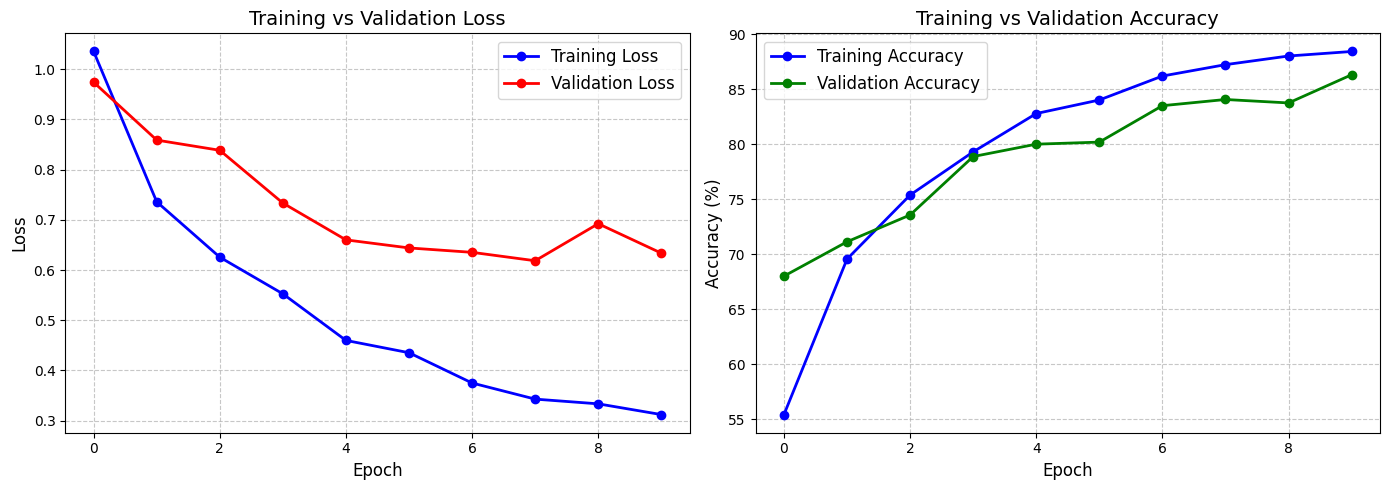

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# =========================
# Graph 1: Loss Comparison
# =========================
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue', marker='o', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='red', marker='o', linewidth=2)
plt.title('Training vs Validation Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# =========================
# Graph 2: Accuracy Comparison
# =========================
plt.subplot(1, 2, 2)
# --- NEW: Added Training Accuracy Line ---
plt.plot(train_accuracies, label='Training Accuracy', color='blue', marker='o', linewidth=2) 
plt.plot(val_accuracies, label='Validation Accuracy', color='green', marker='o', linewidth=2)
plt.title('Training vs Validation Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()